# Plots
Loads all scenario results and produces all figures.
**Run all scenario notebooks first.**

## Overview

This notebook loads the results from all 12 scenario `.pkl` files and generates every figure used in the thesis. **Run all 12 scenario notebooks first** before running this notebook.

The figures are produced in order:

| # | Figure | What it shows |
|---|---|---|
| 1 | Steel stock — medium baseline | Validation of the logistic stock projection against literature values (2008, 2019, 2050, 2100) |
| 2 | Steel stock — all scenarios | Divergence of stock trajectories across Low/Medium/High demand levels (2025–2100) |
| 3 | Total crude steel production | Annual inflow (demand) across demand levels vs WSA historic production |
| Validation | Historic inflow vs WSA | Model-to-data comparison for 1945–2025 |
| Route bars | Production by route in 2050 | Stacked bars: BF-BOF / H-DRI / EAF share per scenario in 2050 |
| 4 | H-DRI production — all scenarios | S-curve ramp-up of H-DRI by demand level and ambition |
| 5 | Annual CO₂ emissions | Emissions trajectories with IEA NZE 2030 and 2050 targets |
| 5b | Cumulative CO₂ | Cumulative emissions vs 108 Gt steel-sector 2°C budget |
| 6 | Emissions by route | Stacked area: BF-BOF vs H-DRI vs EAF emission contributions |
| 7a | Electrolyser electricity vs REMIND | Electrolyser electricity demand vs SSP projected electrolysis supply |
| 7b | H₂ demand vs REMIND | Steel sector H₂ demand vs SSP projected green H₂ supply |
| 8 | Total electrolyser capacity | Installed GW across scenarios |
| 8b | Annual deployment | GW/yr of new capacity + replacements |
| 8c | Deployment by technology | Stacked: AWE / PEMWE / Other annual additions |
| 9 | Nickel demand | kt/yr for AWE electrolysers vs 2024 global supply |
| 10 | Iridium demand | t/yr for PEMWE electrolysers vs available iridium supply (WPIC 2023 projection) |
| 11 | Platinum demand | t/yr for PEMWE electrolysers vs 2024 global supply |
| DSM | DSM by sector | Historic inflow/outflow/stock-change per end-use sector (1700–2025) |

To save a figure, uncomment the `fig.savefig(...)` line at the bottom of the relevant cell. Figures are saved to `../visualizations/`.

## Load all scenario results

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, PchipInterpolator
import seaborn as sns
from pathlib import Path
from model_functions import load_remind_data
from model_functions import compare_remind_h2
from model_functions import run_scenario
# Legends
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
    'figure.titlesize': 20,
    'savefig.bbox': 'tight',
    'savefig.dpi': 300,
})

data_folder = Path.cwd().parent / 'data' / 'processed'
raw_folder  = Path.cwd().parent / 'data' / 'raw'

scenario_files = {
    'L-Baseline': 'low_baseline.pkl',
    'L-DRI Scale-Up': 'low_dri.pkl',
    'L-Technology': 'low_tech.pkl',
    'L-Full Transition': 'low_full.pkl',
    'M-Baseline': 'med_baseline.pkl',
    'M-DRI Scale-Up': 'med_dri.pkl',
    'M-Technology': 'med_tech.pkl',
    'M-Full Transition': 'med_full.pkl',    
    'H-Baseline': 'high_baseline.pkl',
    'H-DRI Scale-Up': 'high_dri.pkl',
    'H-Technology': 'high_tech.pkl',
    'H-Full Transition': 'high_full.pkl'
}

scenarios = {}
for name, fname in scenario_files.items():
    with open(data_folder / fname, 'rb') as f:
        scenarios[name] = pickle.load(f)
    print(f'Loaded: {name}')

# Shared
baseline   = scenarios['M-Baseline']
years      = baseline['years']
plot_years = baseline['plot_years']

sc_colors = {
    'Baseline':          '#4a4a4a',
    'Full transition':   '#1a5c3a',
    'Delayed transition':'#8B1A1A',
    'Circular Economy':  '#1B4F8A',
    'Technology':        '#0D6B5E',
}

wsa_years  = list(baseline['wsa_production'].keys())
wsa_values = [v * 1e6 for v in baseline['wsa_production'].values()]

remind_folder = Path.cwd().parent / 'data' / 'raw' / 'future'

file_paths = {
    'SSP2 Current policies':  remind_folder / 'REMIND_generic_C_SMIPv08-M-SSP2-NPi2025-def-rem-6.mif',
    'SSP2 Carbon price ~400': remind_folder / 'REMIND_generic_C_SMIPv08-L-SSP2-PkPrice400-def-rem-6.mif',
    'SSP1 Ambitious':         remind_folder / 'REMIND_generic_C_SMIPv08-VLLO-SSP1-PkPrice500-def-rem-6.mif',
}

remind_colors = {
    'SSP2 Current policies':  '#8B1A1A',
    'SSP2 Carbon price ~400': '#cf9140',
    'SSP1 Ambitious':         '#1a5c3a',
}

remind_styles = {
    'SSP2 Current policies':  ('SSP2 Current policies',  '#8B1A1A', '--'),
    'SSP2 Carbon price ~400': ('SSP2 Carbon price ~400', '#cf9140', '--'),
    'SSP1 Ambitious':         ('SSP1 Ambitious',         '#1a5c3a', '--'),
}
ssp_styles = remind_styles

remind_data   = load_remind_data(file_paths)
remind_years  = list(remind_data.values())[0]['years']
h2_interp     = compare_remind_h2(scenarios, remind_data)

demand_levels   = ['L', 'M', 'H']
ambition_levels = ['Baseline', 'DRI Scale-Up', 'Technology', 'Full Transition']

demand_labels = {
    'L': 'Low demand (6 t/capita)',
    'M': 'Medium demand (11 t/capita)',
    'H': 'High demand (14 t/capita)',
}

demand_colors = {
    'L': '#2e7d32',
    'M': '#e65100',
    'H': '#b71c1c',
}

ambition_styles = {
    'Baseline':        ':',
    'DRI Scale-Up':    '--',
    'Technology':      '-.',
    'Full Transition': '-',
}

ambition_widths = {
    'Baseline': 1.2, 'DRI Scale-Up': 1.5,
    'Technology': 1.8, 'Full Transition': 2.2,
}

# Electrolyser electricity demand (TWh/yr) — capacity × availability hours
available_hours = (8760 - 11*24) * (1 - 0.03)
elec = {}
for name, sc in scenarios.items():
    cap = sc['cap_results']
    elec[name] = (cap['AEC'] + cap['PEM'] + cap['Other']) * available_hours / 1000

# Visualization output folders
viz_root = Path.cwd().parent / 'visualizations'
viz = {
    'steel':        viz_root / 'steel',
    'emissions':    viz_root / 'emissions',
    'hydrogen':     viz_root / 'hydrogen',
    'electrolyzer': viz_root / 'electrolyzer',
    'CRM':          viz_root / 'CRM',
    'sensitivity':  viz_root / 'sensitivity',
}
for folder in viz.values():
    folder.mkdir(parents=True, exist_ok=True)

# Supply reference data
supply_ref           = pd.read_csv(raw_folder / 'material_intensities' / 'supply_references.csv', index_col='material')
nickel_supply_2024   = float(supply_ref.loc['nickel_kt',              'value'])
iridium_supply_2024  = float(supply_ref.loc['iridium_t',              'value'])
other_demand         = float(supply_ref.loc['iridium_other_demand_t', 'value'])
platinum_supply_2024 = float(supply_ref.loc['platinum_t',             'value'])

wpic_df              = pd.read_csv(raw_folder / 'material_intensities' / 'iridium_available_wpic.csv')
ir_available_interp  = PchipInterpolator(wpic_df['year'].tolist(), wpic_df['available_t'].tolist())

Loaded: L-Baseline
Loaded: L-DRI Scale-Up
Loaded: L-Technology
Loaded: L-Full Transition
Loaded: M-Baseline
Loaded: M-DRI Scale-Up
Loaded: M-Technology
Loaded: M-Full Transition
Loaded: H-Baseline
Loaded: H-DRI Scale-Up
Loaded: H-Technology
Loaded: H-Full Transition


Loaded: SSP2 Current policies  |  Green H2 2050: 50.9 Mt  |  Renew elec 2050: 53562 TWh  |  Electrolysis elec 2050: 2751 TWh


Loaded: SSP2 Carbon price ~400  |  Green H2 2050: 109.7 Mt  |  Renew elec 2050: 64298 TWh  |  Electrolysis elec 2050: 5925 TWh


Loaded: SSP1 Ambitious  |  Green H2 2050: 301.7 Mt  |  Renew elec 2050: 88673 TWh  |  Electrolysis elec 2050: 16304 TWh


## 1. Total in-use steel stock — baseline

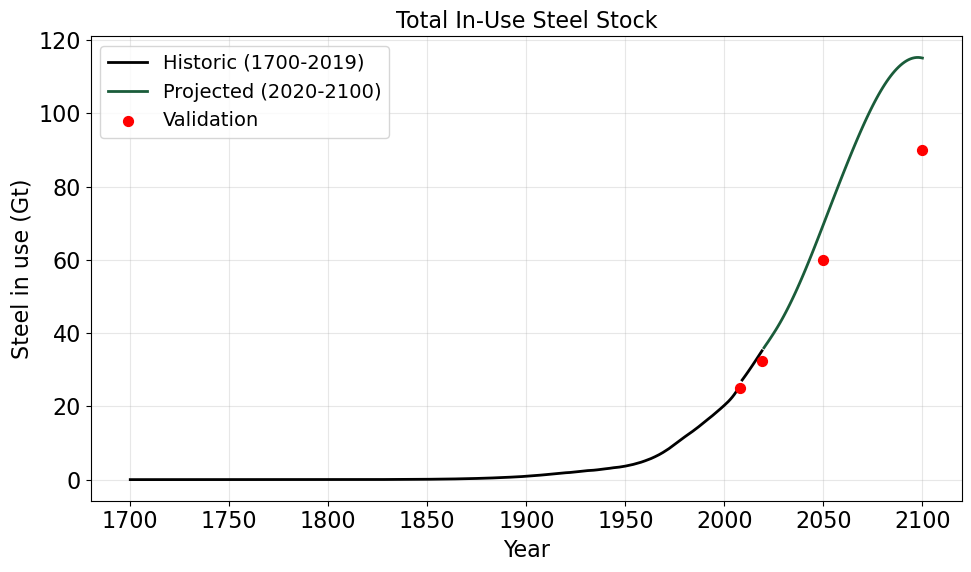

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
stock_df = baseline['stock_df']
hist   = stock_df[stock_df['type']=='historic']
recent = stock_df[stock_df['type']=='recent']
pred   = stock_df[stock_df['type']=='predicted']
ax.plot(hist['year'],   hist['total_stock']/1e9, color='black',   linewidth=2,   label='Historic (1700-2019)')
ax.plot(recent['year'], recent['total_stock']/1e9, color='black', linewidth=2)
ax.plot(pred['year'],   pred['total_stock']/1e9,  color='#1a5c3a', linewidth=2, label='Projected (2020-2100)')
ax.scatter([2008, 2019, 2050, 2100], [25, 32.3, 60, 90], color='red', zorder=5, s=50, label='Validation')
ax.set_xlabel('Year'); ax.set_ylabel('Steel in use (Gt)')
ax.set_title('Total In-Use Steel Stock')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

fig.savefig(viz['steel'] / 'steel_stock_validation.png', dpi=300)

## 2. Total steel stock — all scenarios

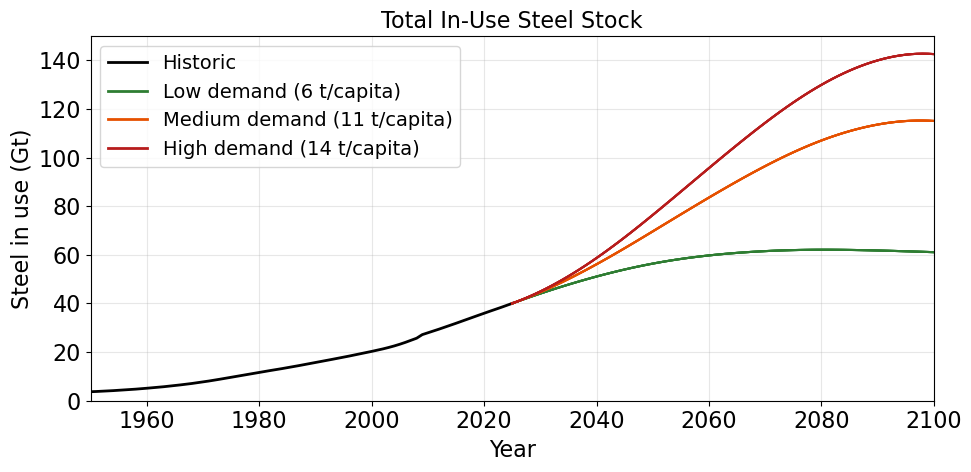

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
historic_plotted = False

for name, sc in scenarios.items():
    demand = name.split('-')[0]
    color  = demand_colors[demand]
    df     = sc['stock_df']

    pre2025  = df[df['year'] <= 2025]
    post2025 = df[df['year'] >= 2025]

    if not historic_plotted:
        ax.plot(pre2025['year'], pre2025['total_stock'] / 1e9,
                color='black', linewidth=2, label='Historic')
        historic_plotted = True

    ax.plot(post2025['year'], post2025['total_stock'] / 1e9,
            color=color, linewidth=1.5)

demand_handles = [
    Line2D([0], [0], color=demand_colors['L'], linewidth=2, label='Low demand (6 t/capita)'),
    Line2D([0], [0], color=demand_colors['M'], linewidth=2, label='Medium demand (11 t/capita)'),
    Line2D([0], [0], color=demand_colors['H'], linewidth=2, label='High demand (14 t/capita)'),
]
historic_handle = [Line2D([0], [0], color='black', linewidth=2, label='Historic')]

ax.set_xlabel('Year'); ax.set_ylabel('Steel in use (Gt)')
ax.set_title('Total In-Use Steel Stock')
ax.set_xlim(1950, 2100); ax.set_ylim(0)
ax.grid(True, alpha=0.3)
plt.legend(handles=historic_handle + demand_handles, loc='upper left')
plt.tight_layout()
plt.show()

fig.savefig(viz['steel'] / 'steel_stock_projection.png', dpi=300)

## 3. Total crude steel needed (inflow)

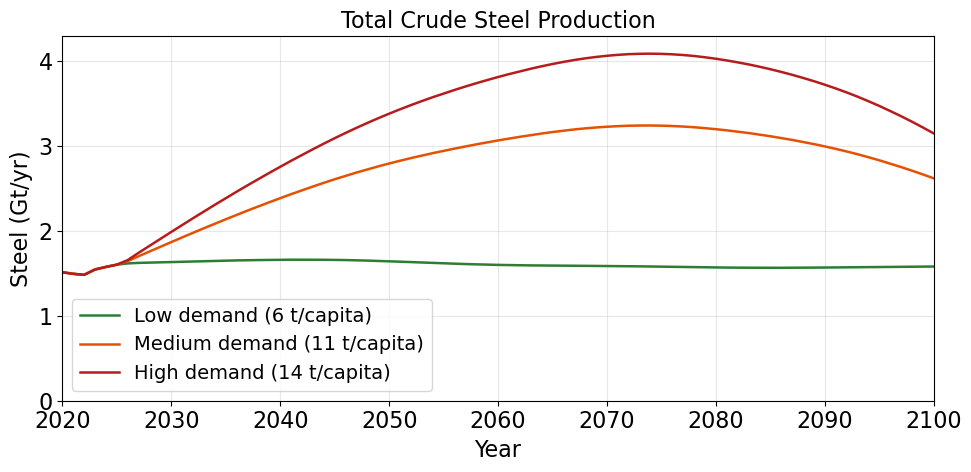

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

# One validation line per demand level (baselines only)
validation_scenarios = {
    'L-Baseline': ('Low demand (6 t/capita)',  demand_colors['L']),
    'M-Baseline': ('Medium demand (11 t/capita)', demand_colors['M']),
    'H-Baseline': ('High demand (14 t/capita)', demand_colors['H']),
}

for sc_name, (label, color) in validation_scenarios.items():
    results = scenarios[sc_name]['results']
    ax.plot(results['Year'], results['total_steel_needed'] / 1e9,
            color=color, linewidth=1.8, label=label)

# WSA validation scatter
#ax.scatter(wsa_years, [v / 1e9 for v in wsa_values],
#           color='red', s=20, zorder=5, label='World Steel Association')

ax.set_xlabel('Year'); ax.set_ylabel('Steel (Gt/yr)')
ax.set_title('Total Crude Steel Production')
ax.set_xlim(2020, 2100); ax.set_ylim(0)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig.savefig(viz['steel'] / 'steel_inflow_scenarios.png', dpi=300)

# Inflow Validation

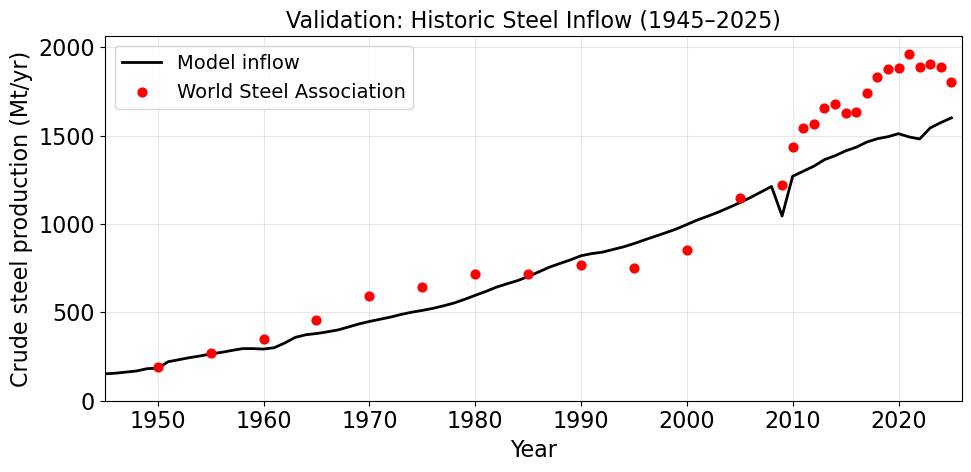

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

results = scenarios['M-Baseline']['results']
mask = results['Year'] <= 2025
ax.plot(results['Year'][mask], results['total_steel_needed'][mask] / 1e6,
        color='black', linewidth=2, label='Model inflow')

wsa_hist = [(yr, val) for yr, val in zip(wsa_years, wsa_values) if yr <= 2025]
if wsa_hist:
    wsa_x, wsa_y = zip(*wsa_hist)
    ax.scatter(wsa_x, [v / 1e6 for v in wsa_y],
               color='red', s=40, zorder=5, label='World Steel Association')

ax.set_xlabel('Year')
ax.set_ylabel('Crude steel production (Mt/yr)')
ax.set_title('Validation: Historic Steel Inflow (1945–2025)')
ax.set_xlim(1945, 2026)
ax.set_ylim(0)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(viz['steel'] / 'steel_inflow_validation.png', dpi=300)
plt.show()

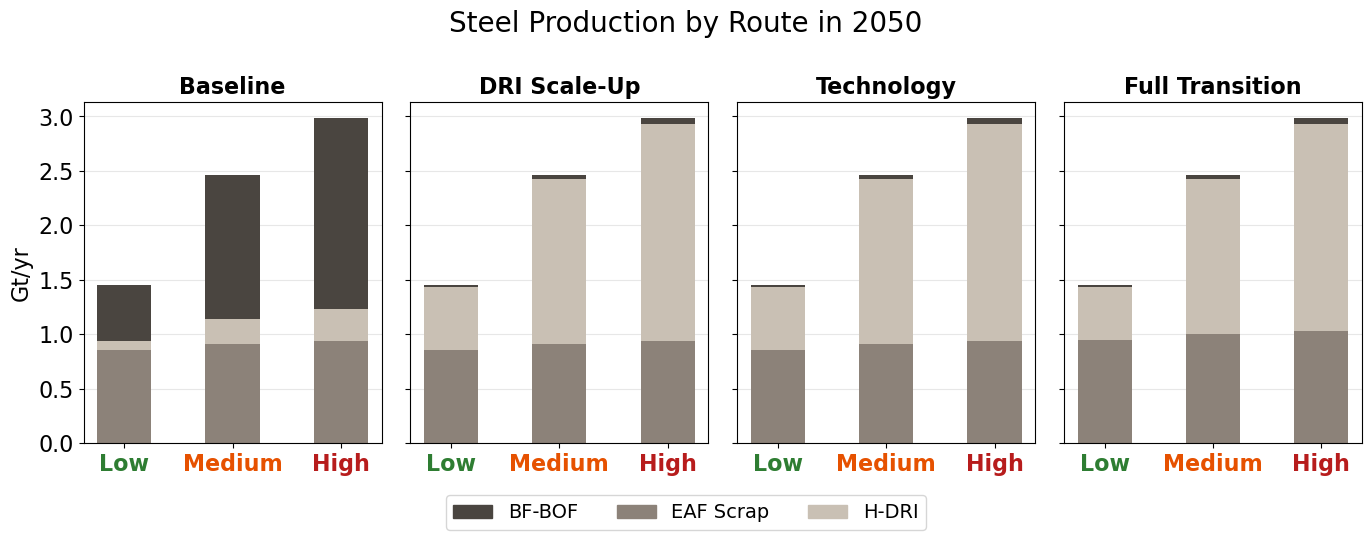

In [6]:
idx_2050 = int(np.where(plot_years == 2050)[0][0])

ROUTE_COLORS = {
    'BF-BOF':    "#4a4540",
    'EAF Scrap': "#8c8279",
    'H-DRI':     "#c9c0b4",
}

x     = np.arange(len(demand_levels))
w     = 0.5
xlbls = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)
fig.suptitle('Steel Production by Route in 2050')

for col, ambition in enumerate(ambition_levels):
    ax = axes[col]
    for i, demand in enumerate(demand_levels):
        prod = scenarios[f'{demand}-{ambition}']['production']
        bf   = prod['BF Production'][idx_2050]  / 1e9
        eaf  = prod['EAF Scrap'][idx_2050]       / 1e9
        dri  = prod['DRI Production'][idx_2050]  / 1e9

        ax.bar(i, eaf, width=w, color=ROUTE_COLORS['EAF Scrap'])
        ax.bar(i, dri, width=w, color=ROUTE_COLORS['H-DRI'],  bottom=eaf)
        ax.bar(i, bf,  width=w, color=ROUTE_COLORS['BF-BOF'], bottom=eaf + dri)

    ax.set_title(ambition, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(xlbls)
    for tick, demand in zip(ax.get_xticklabels(), demand_levels):
        tick.set_color(demand_colors[demand])
        tick.set_fontweight('bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

axes[0].set_ylabel('Gt/yr')

legend_handles = [mpatches.Patch(color=c, label=l) for l, c in ROUTE_COLORS.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08))
fig.tight_layout()
plt.show()
fig.savefig(viz['steel'] / 'steel_production_routes_2050.png', dpi=300, bbox_inches='tight')

## 4. Steel supply transition — baseline

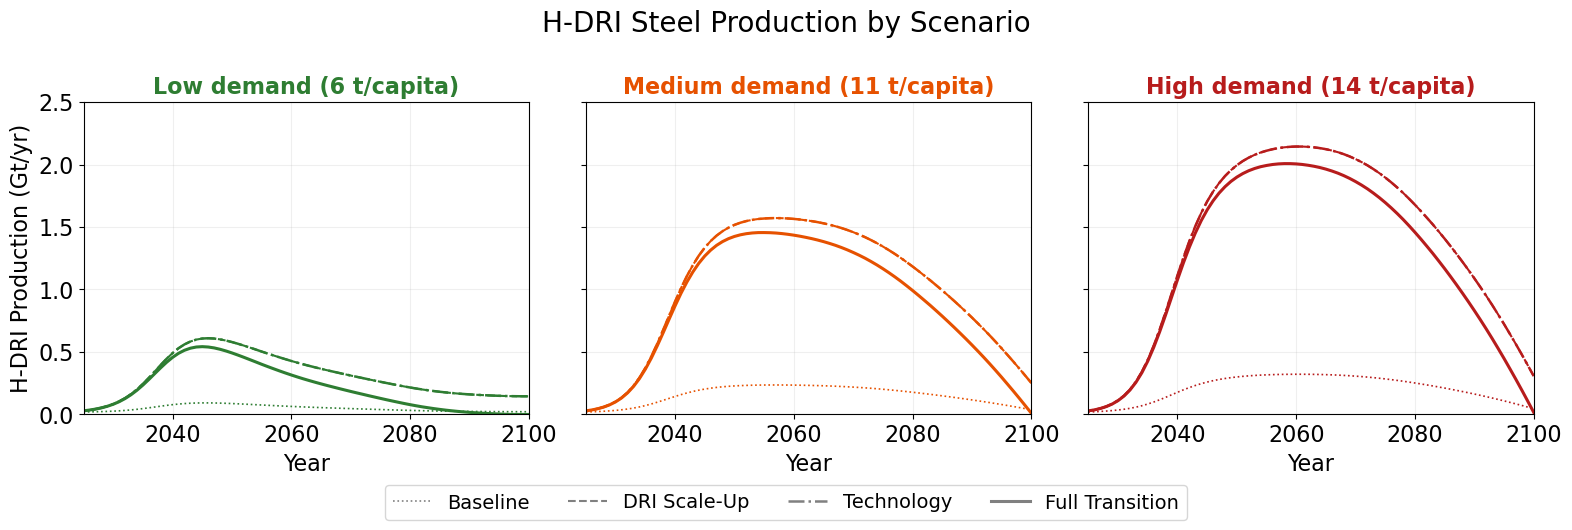

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle('H-DRI Steel Production by Scenario')

for c, demand in enumerate(demand_levels):
    ax = axes[c]
    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        dri  = scenarios[name]['production']['DRI Production'] / 1e9
        ax.plot(plot_years, dri,
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    ax.set_title(demand_labels[demand], fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2025, 2100); ax.set_ylim(0, 2.5)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('H-DRI Production (Gt/yr)')

ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()

fig.savefig(viz['steel'] / 'DRI_supply.png', dpi=300)

## 5. CO2 emissions — all scenarios

In [8]:
def get_emissions_spliced(sc, plot_years):
    """Return total emissions directly from model output (Gt)."""
    raw = sc['emissions']
    return ((raw['BF Emissions'] + raw['H-DRI Emissions'] +
             raw['EAF Emissions']) / 1000).copy()

em = {name: get_emissions_spliced(sc, plot_years)
      for name, sc in scenarios.items()}

print(f"M-Baseline 2022: {em['M-Baseline'][0]:.3f} Gt")
print(f"M-Baseline 2025: {em['M-Baseline'][3]:.3f} Gt")

M-Baseline 2022: 2.033 Gt
M-Baseline 2025: 2.182 Gt


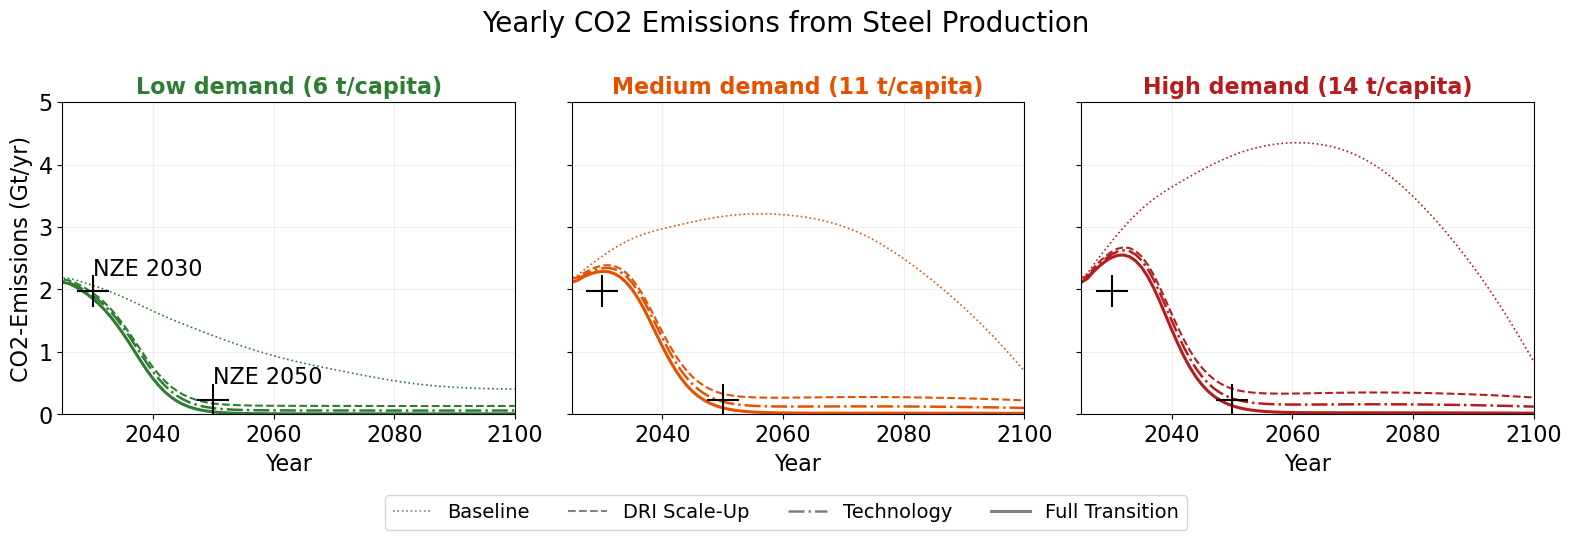

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle('Yearly CO2 Emissions from Steel Production')

iea_2030_target = 1976 / 1e3
iea_2050_target = 234  / 1e3

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        ax.plot(plot_years, em[name],
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition],
                label=ambition)

    ax.scatter(2030, iea_2030_target, color='black', s=500, zorder=50, marker='+', label='IEA NZE 2030 target')
    ax.scatter(2050, iea_2050_target, color='black', s=500, zorder=50, marker='+', label='IEA NZE 2050 target')

    if c == 0:
        ax.text(2030, iea_2030_target + 0.25, 'NZE 2030')
        ax.text(2050, iea_2050_target + 0.25, 'NZE 2050')

    ax.set_title(demand_labels[demand], fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2025, 2100); ax.set_ylim(0, 5)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('CO2-Emissions (Gt/yr)')

ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.show()

fig.savefig(viz['emissions'] / 'steel_emissions_scenarios.png', dpi=300)

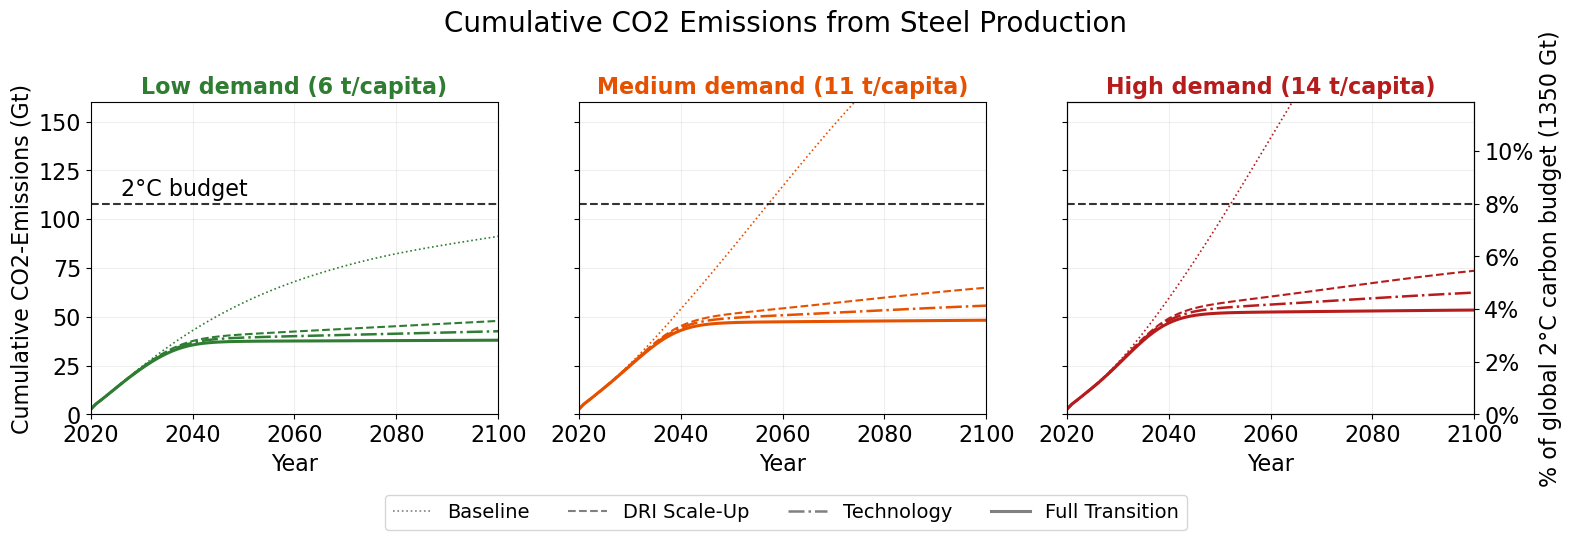

In [10]:
# Pre-2022 emissions from WSA (same for all scenarios — WSA-anchored)
bfbof_share_pre = {2020: 0.710, 2021: 0.705}
eaf_fac_approx  = float(baseline['emissions_factor_EAF'][0])  # 2022 value as approx

pre_years = np.array([2020, 2021])
pre_em = []
for yr in pre_years:
    wsa_mt   = baseline['wsa_production'][yr]
    bf_share = bfbof_share_pre[yr]
    bf_em    = wsa_mt / 1000 * bf_share * 1.85
    eaf_em   = wsa_mt / 1000 * (1 - bf_share) * eaf_fac_approx
    pre_em.append(bf_em + eaf_em)
pre_em = np.array(pre_em)

ext_years  = np.concatenate([pre_years, plot_years])
em_ext     = {name: np.concatenate([pre_em, em[name]]) for name in scenarios}
em_cum_ext = {name: np.cumsum(em_ext[name]) for name in scenarios}

budget_2c = 108  # Steel sector proportional share of IPCC AR6 2°C budget

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle('Cumulative CO2 Emissions from Steel Production')

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        ax.plot(ext_years, em_cum_ext[name],
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition],
                label=ambition)

    ax.axhline(budget_2c, color='black', linewidth=1.5, linestyle='--', alpha=0.8)
    if c == 0:
        ax.text(2026, budget_2c + 1.5, '2°C budget', color='black', va='bottom')

    ax.set_title(demand_labels[demand], fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2020, 2100)
    ax.set_ylim(0, 160)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Cumulative CO2-Emissions (Gt)')

ax2 = axes[2].twinx()
budget_total = 1350
ax2.set_ylim(0 / budget_total * 100, 160 / budget_total * 100)
ax2.set_ylabel('% of global 2°C carbon budget (1350 Gt)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.show()

fig.savefig(viz['emissions'] / 'steel_cumulative_emissions_scenarios.png', dpi=300)

## 6. CO2 by route

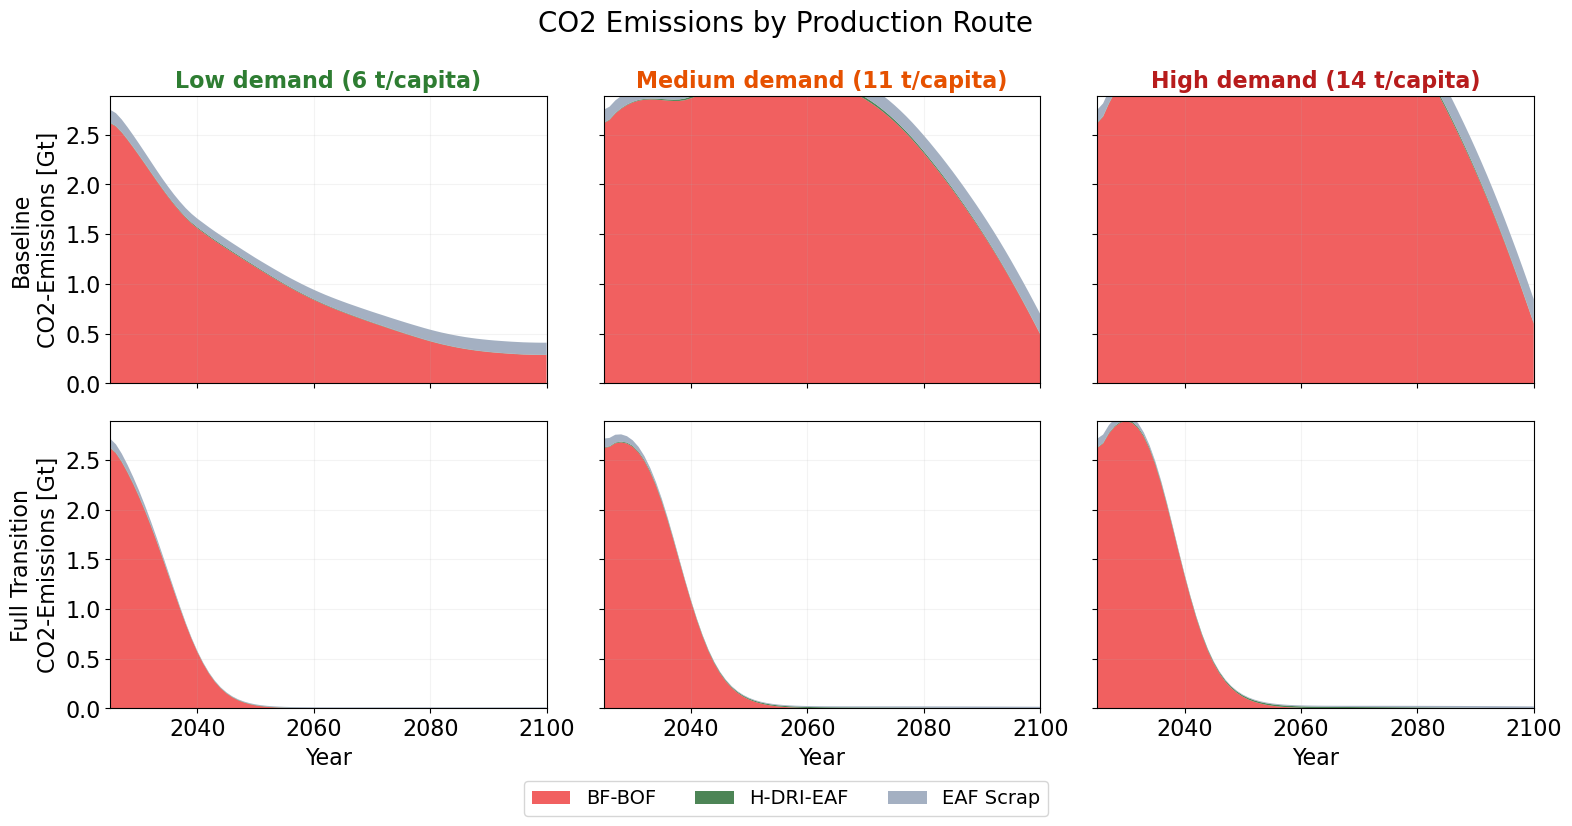

In [11]:
def get_route_emissions(sc, plot_years, iea_2022_emissions=2.6):
    em     = sc['emissions']
    bf_em  = em['BF Emissions']    / 1000
    dri_em = em['H-DRI Emissions'] / 1000
    eaf_em = em['EAF Emissions']   / 1000
    scale  = iea_2022_emissions / (bf_em[0] + dri_em[0] + eaf_em[0])
    t      = np.clip((plot_years - 2022) / (2040 - 2022), 0, 1)
    taper  = 0.5 * (1 - np.cos(np.pi * t))
    calib  = scale * (1 - taper) + 1.0 * taper
    return bf_em * calib, dri_em * calib, eaf_em * calib

route_rows   = ['Baseline', 'Full Transition']
route_colors = ['#ef4444', '#2e7038', '#94a3b8']
route_labels = ['BF-BOF', 'H-DRI-EAF', 'EAF Scrap']

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True, sharex=True)
fig.suptitle('CO2 Emissions by Production Route')

for r, ambition in enumerate(route_rows):
    for c, demand in enumerate(demand_levels):
        ax  = axes[r][c]
        sc  = scenarios[f'{demand}-{ambition}']
        bf, dri, eaf = get_route_emissions(sc, plot_years)

        ax.stackplot(plot_years, bf, dri, eaf, colors=route_colors, alpha=0.85)
        ax.set_xlim(2025, 2100); ax.set_ylim(0)
        ax.grid(alpha=0.15)

        if r == 0:
            ax.set_title(demand_labels[demand], fontweight='bold', color=demand_colors[demand])
        if c == 0:
            ax.set_ylabel(f'{ambition}\nCO2-Emissions [Gt]')
        if r == 1:
            ax.set_xlabel('Year')

from matplotlib.patches import Patch
route_handles = [Patch(facecolor=c, alpha=0.85, label=l)
                 for c, l in zip(route_colors, route_labels)]
fig.legend(handles=route_handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig(viz['emissions'] / 'steel_emissions_by_route.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Hydrogen demand — all scenarios

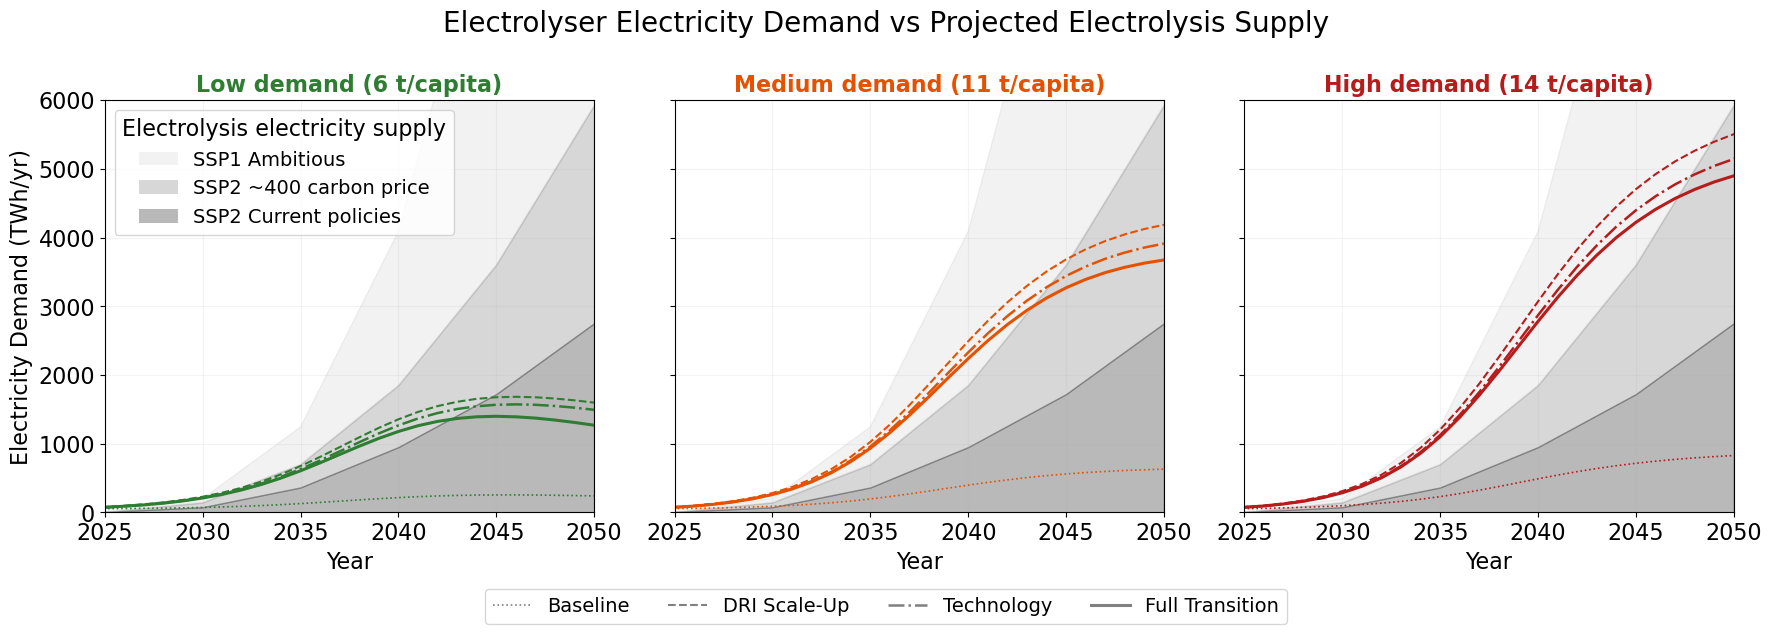

In [12]:
# Interpolate SSP to annual years for smooth fill_between
annual_years = np.arange(2025, 2051)
ssp_annual   = {}
for ssp_name in remind_styles:
    f = interp1d(remind_years,
                 remind_data[ssp_name]['electrolysis_electricity'],
                 kind='linear', fill_value='extrapolate')
    ssp_annual[ssp_name] = f(annual_years)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)
fig.suptitle('Electrolyser Electricity Demand vs Projected Electrolysis Supply')

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    ax.fill_between(annual_years, 0,
                    ssp_annual['SSP2 Current policies'],
                    alpha=0.3, color="#171717")
    ax.fill_between(annual_years,
                    ssp_annual['SSP2 Current policies'],
                    ssp_annual['SSP2 Carbon price ~400'],
                    alpha=0.2, color="#373737")
    ax.fill_between(annual_years,
                    ssp_annual['SSP2 Carbon price ~400'],
                    ssp_annual['SSP1 Ambitious'],
                    alpha=0.1, color="#838383")

    for ssp_name, (_, color, _) in remind_styles.items():
        ax.plot(annual_years, ssp_annual[ssp_name],
                color=color, linewidth=0, linestyle='-')

    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        ax.plot(plot_years, elec[name],
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    ax.set_title(demand_labels[demand], fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2025, 2050); ax.set_ylim(0, 6000)
    ax.grid(True, alpha=0.15)

from matplotlib.patches import Patch
ssp_handles = [
    Patch(facecolor='#838383', alpha=0.1, label='SSP1 Ambitious'),
    Patch(facecolor='#373737', alpha=0.2, label='SSP2 ~400 carbon price'),
    Patch(facecolor='#171717', alpha=0.3, label='SSP2 Current policies'),
]
axes[0].legend(handles=ssp_handles, title='Electrolysis electricity supply', loc='upper left')
axes[0].set_ylabel('Electricity Demand (TWh/yr)')

ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()

plt.savefig(viz['electrolyzer'] / 'elec_demand_vs_ssp.png', dpi=300)

plt.show()

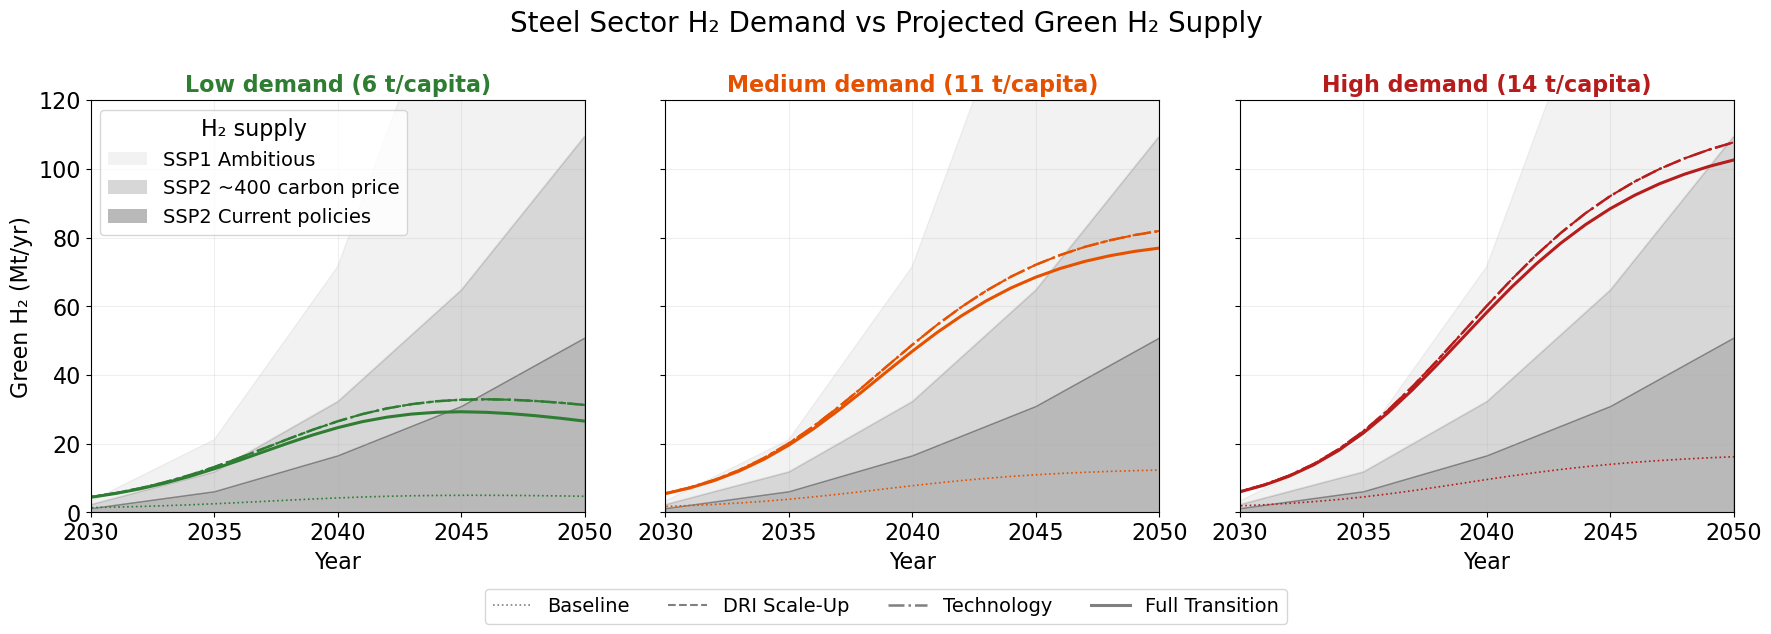

In [13]:
# Interpolate SSP H2 supply to annual years
annual_years_h2 = np.arange(2030, 2051)
ssp_h2_annual   = {}
for ssp_name in ssp_styles:
    f = interp1d(remind_years, remind_data[ssp_name]['green_h2'],
                 kind='linear', fill_value='extrapolate')
    ssp_h2_annual[ssp_name] = f(annual_years_h2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)
fig.suptitle('Steel Sector H₂ Demand vs Projected Green H₂ Supply')

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    ax.fill_between(annual_years_h2, 0,
                    ssp_h2_annual['SSP2 Current policies'],
                    alpha=0.3, color="#171717")
    ax.fill_between(annual_years_h2,
                    ssp_h2_annual['SSP2 Current policies'],
                    ssp_h2_annual['SSP2 Carbon price ~400'],
                    alpha=0.2, color="#373737")
    ax.fill_between(annual_years_h2,
                    ssp_h2_annual['SSP2 Carbon price ~400'],
                    ssp_h2_annual['SSP1 Ambitious'],
                    alpha=0.1, color="#838383")

    for ssp_name, (_, col, _) in ssp_styles.items():
        ax.plot(annual_years_h2, ssp_h2_annual[ssp_name],
                color=col, linewidth=0, linestyle='-')

    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        ax.plot(plot_years, scenarios[name]['h2']['H2 Demand (Mt)'],
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    ax.set_title(demand_labels[demand], fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2030, 2050)
    ax.set_xticks(range(2030, 2051, 5))
    ax.set_ylim(0, 120)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Green H₂ (Mt/yr)')

ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
ssp_patch_handles = [
    Patch(facecolor='#838383', alpha=0.1, label='SSP1 Ambitious'),
    Patch(facecolor='#373737', alpha=0.2, label='SSP2 ~400 carbon price'),
    Patch(facecolor='#171717', alpha=0.3, label='SSP2 Current policies'),
]

fig.legend(handles=ambition_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.06))
axes[0].legend(handles=ssp_patch_handles, title='H₂ supply', loc='upper left')

plt.tight_layout()

plt.savefig(viz['hydrogen'] / 'h2_demand_vs_ssp.png', dpi=300)

plt.show()

## 8. Electrolyser capacity — baseline

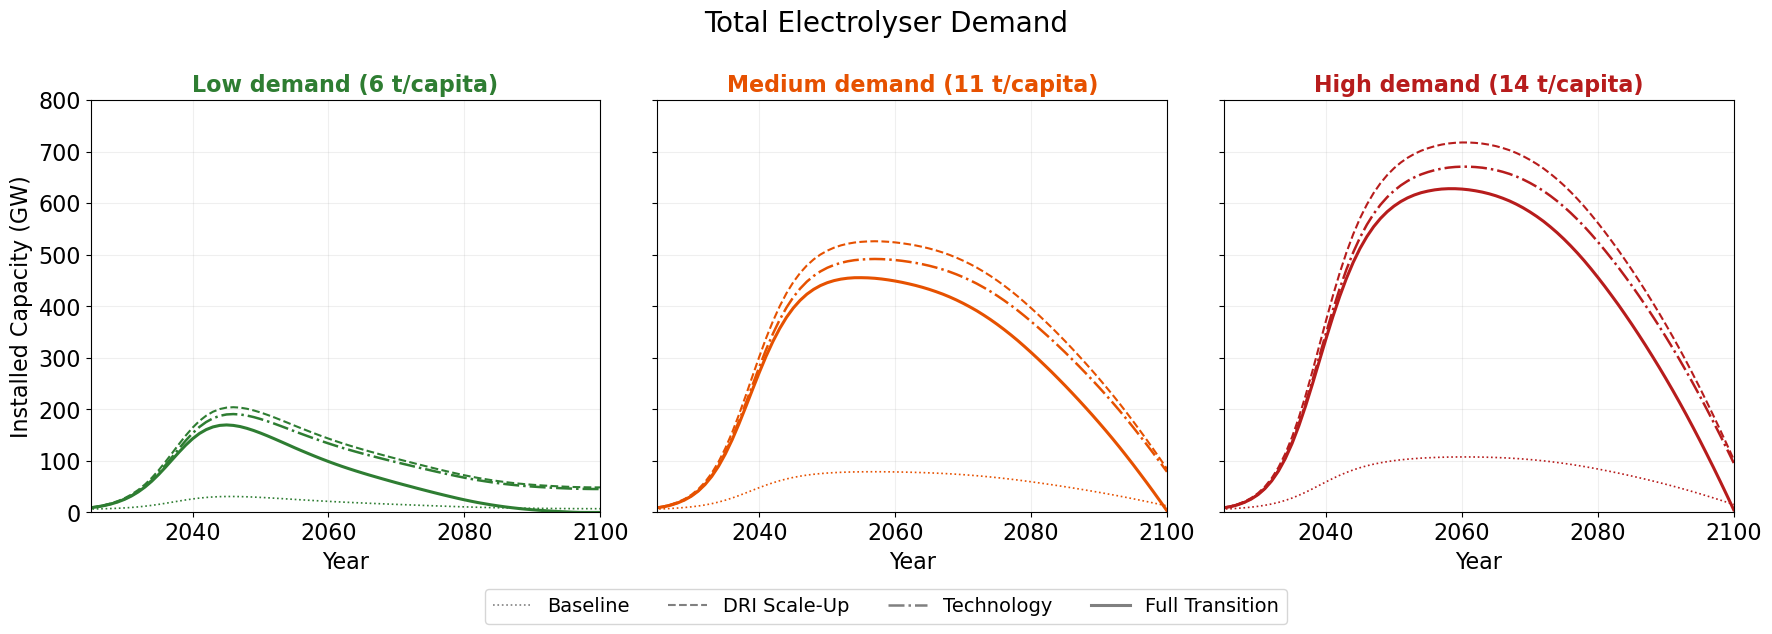

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)
fig.suptitle('Total Electrolyser Demand')

for c, demand in enumerate(demand_levels):
    ax = axes[c]
    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        cap  = scenarios[name]['cap_results']
        total = cap['AEC'] + cap['PEM'] + cap['Other']
        ax.plot(plot_years, total,
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    ax.set_title(demand_labels[demand], fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(plot_years[3], plot_years[-1])
    ax.set_ylim(0, 800)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Installed Capacity (GW)')

from matplotlib.lines import Line2D
ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig(viz['electrolyzer'] / 'electrolyzer_capacity_total_all_scenarios.png', dpi=300, bbox_inches='tight')
plt.show()

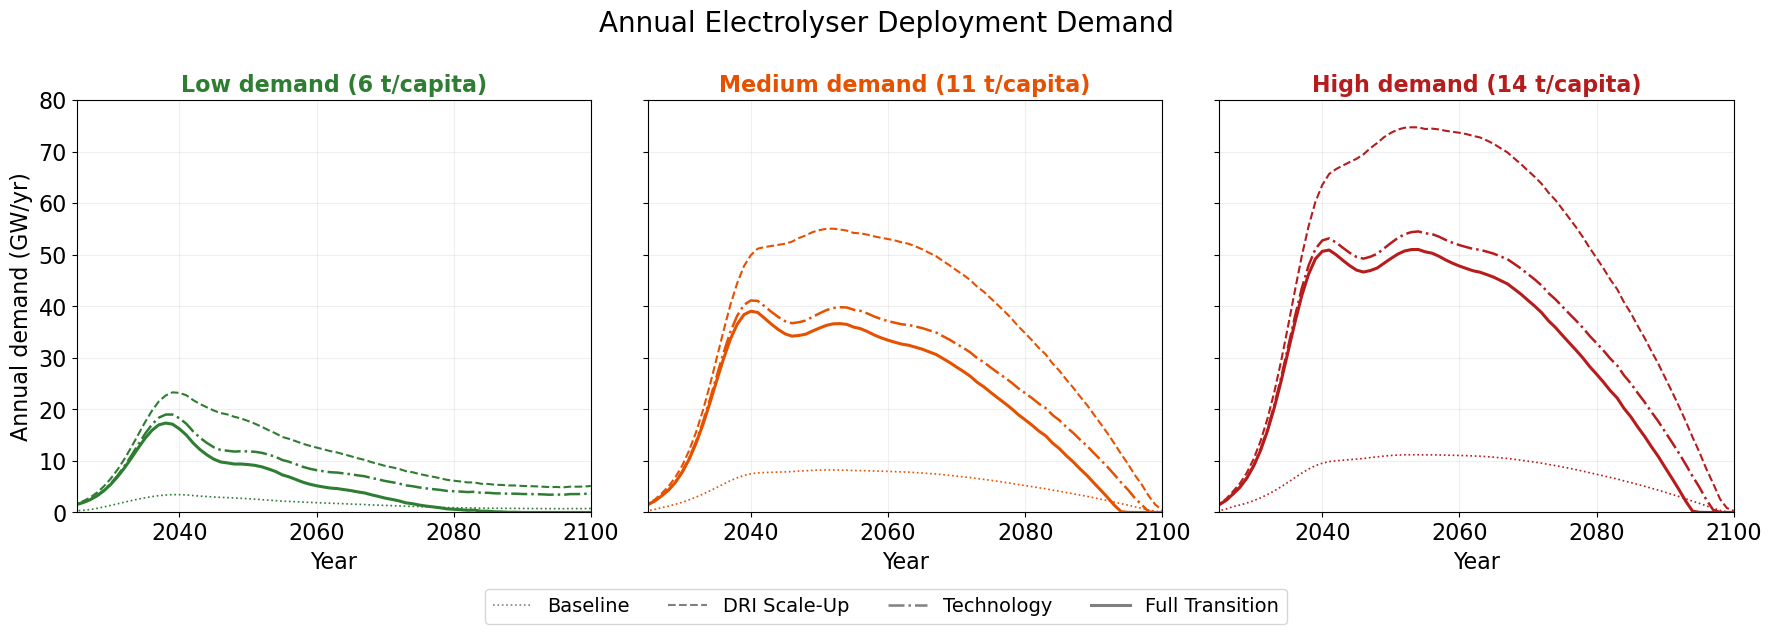

In [15]:
demand_map   = {'L': 'low', 'M': 'med', 'H': 'high'}
ambition_map = {'Baseline': 'baseline', 'DRI Scale-Up': 'dri',
                'Technology': 'tech', 'Full Transition': 'full'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)
fig.suptitle('Annual Electrolyser Deployment Demand')

for c, demand in enumerate(demand_levels):
    ax = axes[c]
    for ambition in ambition_levels:
        sc_name = f'{demand_map[demand]}_{ambition_map[ambition]}'
        with open(data_folder / f'{sc_name}.pkl', 'rb') as f:
            sc = pickle.load(f)
        dsm = sc['dsm_elec']
        total_inflow = dsm['i_AEC'] + dsm['i_PEM'] + dsm['i_Other']
        ax.plot(plot_years, total_inflow,
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    ax.set_title(demand_labels[demand], fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(plot_years[3], plot_years[-1])
    ax.set_ylim(0, 80)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Annual demand (GW/yr)')

from matplotlib.lines import Line2D
ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig(viz['electrolyzer'] / 'electrolyzer_deployment_demand.png', dpi=300, bbox_inches='tight')
plt.show()

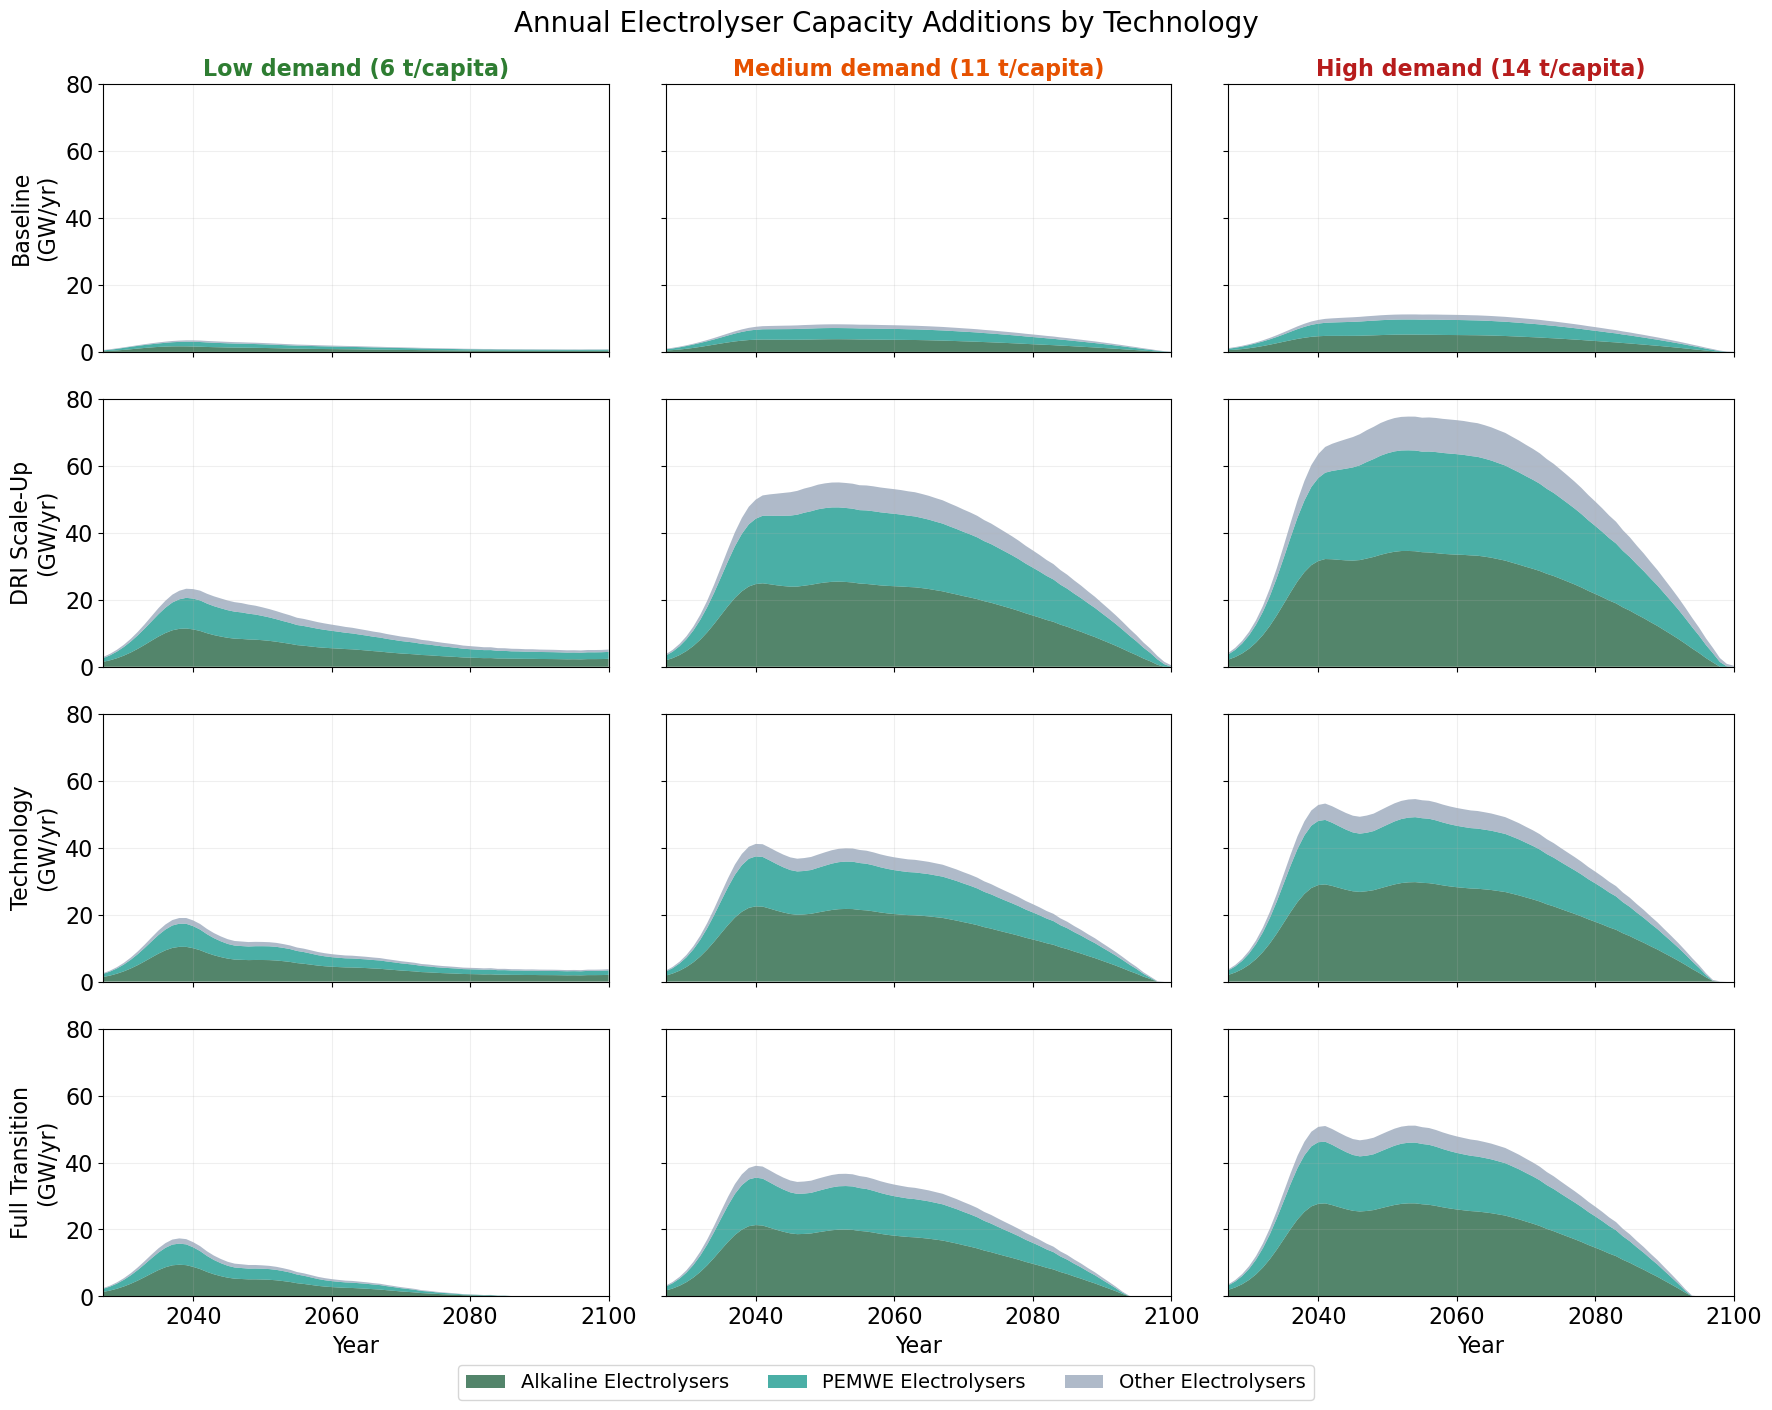

In [16]:
cap_colors = ['#1a5c3a', '#0d9488', '#94a3b8']
cap_labels = ['Alkaline Electrolysers', 'PEMWE Electrolysers', 'Other Electrolysers']

fig, axes = plt.subplots(4, 3, figsize=(18, 14), sharey=True, sharex=True)
fig.suptitle('Annual Electrolyser Capacity Additions by Technology')

for r, ambition in enumerate(ambition_levels):
    for c, demand in enumerate(demand_levels):
        ax  = axes[r][c]
        dsm = scenarios[f'{demand}-{ambition}']['dsm_elec']

        ax.stackplot(plot_years,
                     dsm['i_AEC'], dsm['i_PEM'], dsm['i_Other'],
                     colors=cap_colors, alpha=0.75)

        ax.set_xlim(plot_years[5], plot_years[-1])
        ax.set_ylim(0, 80)
        ax.grid(True, alpha=0.2)

        if r == 0:
            ax.set_title(demand_labels[demand], fontweight='bold', color=demand_colors[demand])
        if c == 0:
            ax.set_ylabel(f'{ambition}\n(GW/yr)')
        if r == 3:
            ax.set_xlabel('Year')

cap_handles = [Patch(facecolor=c, alpha=0.75, label=l)
               for c, l in zip(cap_colors, cap_labels)]
fig.legend(handles=cap_handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(viz['electrolyzer'] / 'electrolyzer_additions_all_scenarios.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Nickel demand for all scenarios

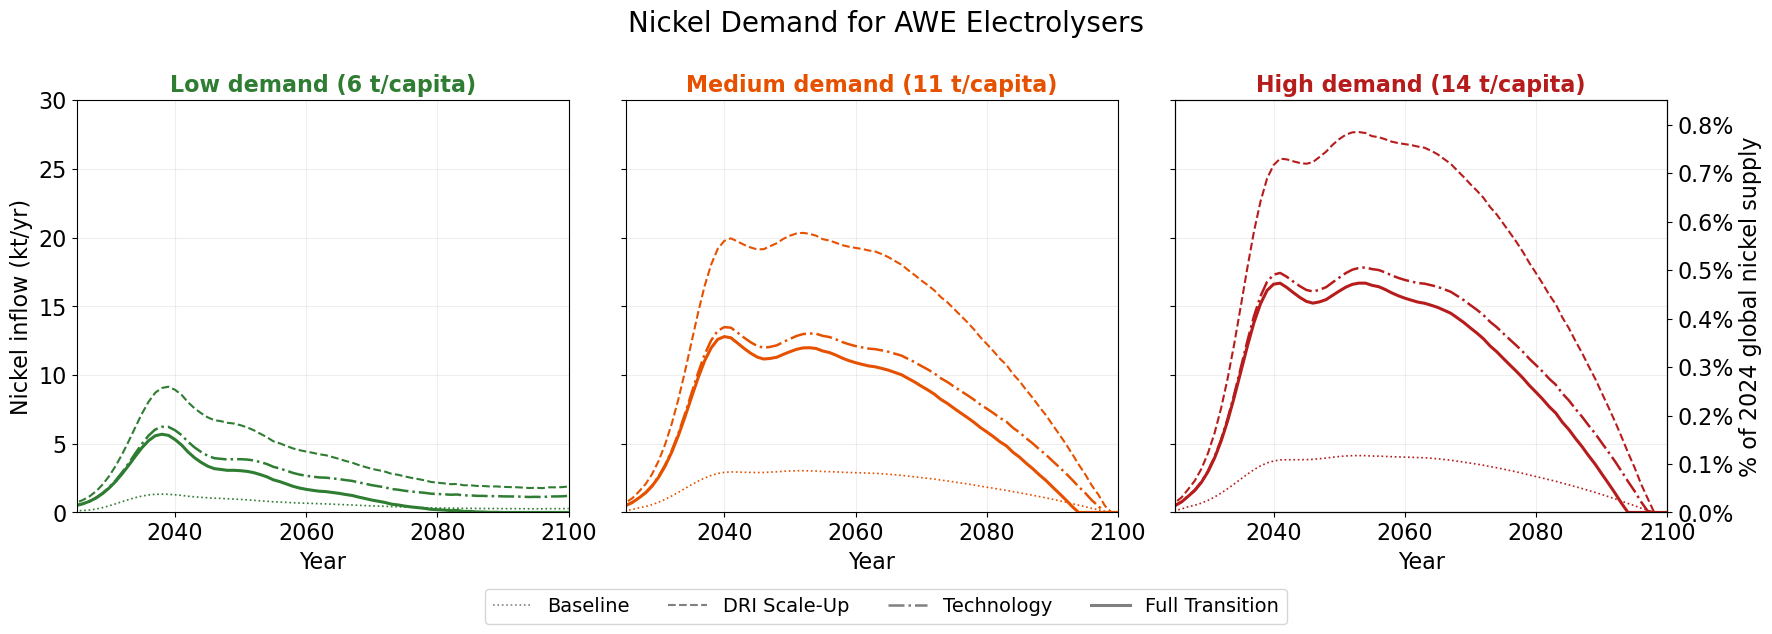

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)
fig.suptitle('Nickel Demand for AWE Electrolysers')

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        ax.plot(scenarios[name]['years'],
                scenarios[name]['materials']['nickel_inflow'],
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    ax.set_title(demand_labels[demand], fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2025, 2100)
    ax.set_ylim(0, 30)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Nickel inflow (kt/yr)')

ax2 = axes[2].twinx()
ax2.set_ylim(0, axes[2].get_ylim()[1] / nickel_supply_2024 * 100)
ax2.set_ylabel('% of 2024 global nickel supply')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

from matplotlib.lines import Line2D
ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
fig.savefig(viz['CRM'] / 'nickel_demand_aec_electrolyzers.png', dpi=300)
plt.show()

## 10. Iridium demand vs supply constraint for all scenarios

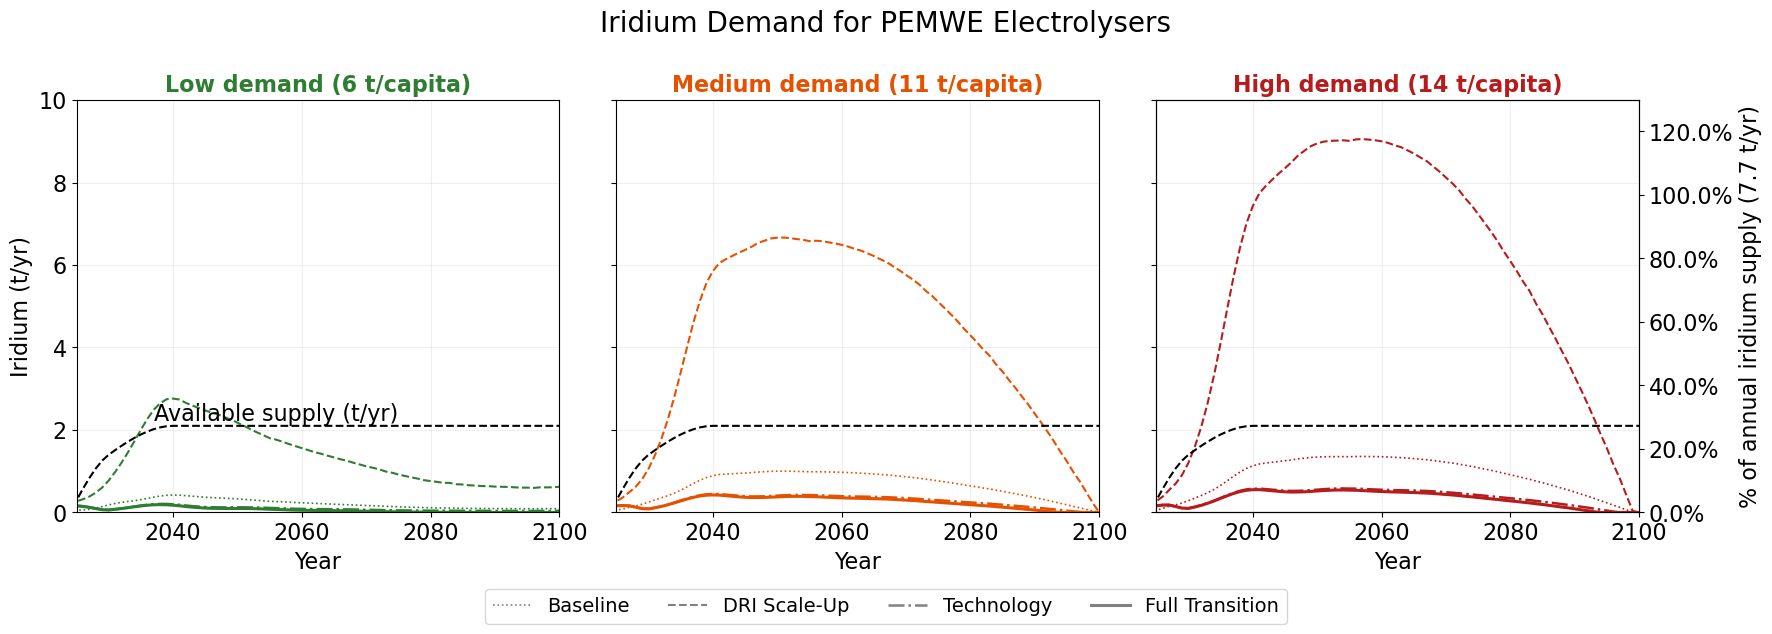

In [18]:
available    = iridium_supply_2024 - other_demand
ir_available = ir_available_interp(years)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)
fig.suptitle('Iridium Demand for PEMWE Electrolysers')

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        ir   = scenarios[name]['materials']['iridium_inflow'] * 1000  # kt → t
        ax.plot(scenarios[name]['years'], ir,
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    if c == 0:
        ax.text(2037, available + 1.8, f'Available supply (t/yr)', va='bottom')

    ax.plot(years, ir_available, linestyle='--', color='black', linewidth=1.5,
        label='Iridium available for electrolysers (WPIC, 2023)')

    ax.set_title(demand_labels[demand], fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2025, 2100)
    ax.set_ylim(0, 10)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Iridium (t/yr)')

ax2 = axes[2].twinx()
ax2.set_ylim(0, axes[2].get_ylim()[1] / iridium_supply_2024 * 100)
ax2.set_ylabel('% of annual iridium supply (7.7 t/yr)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

from matplotlib.lines import Line2D
ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
fig.savefig(viz['CRM'] / 'iridium_demand_all_scenarios.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Pt demand for all scenarios

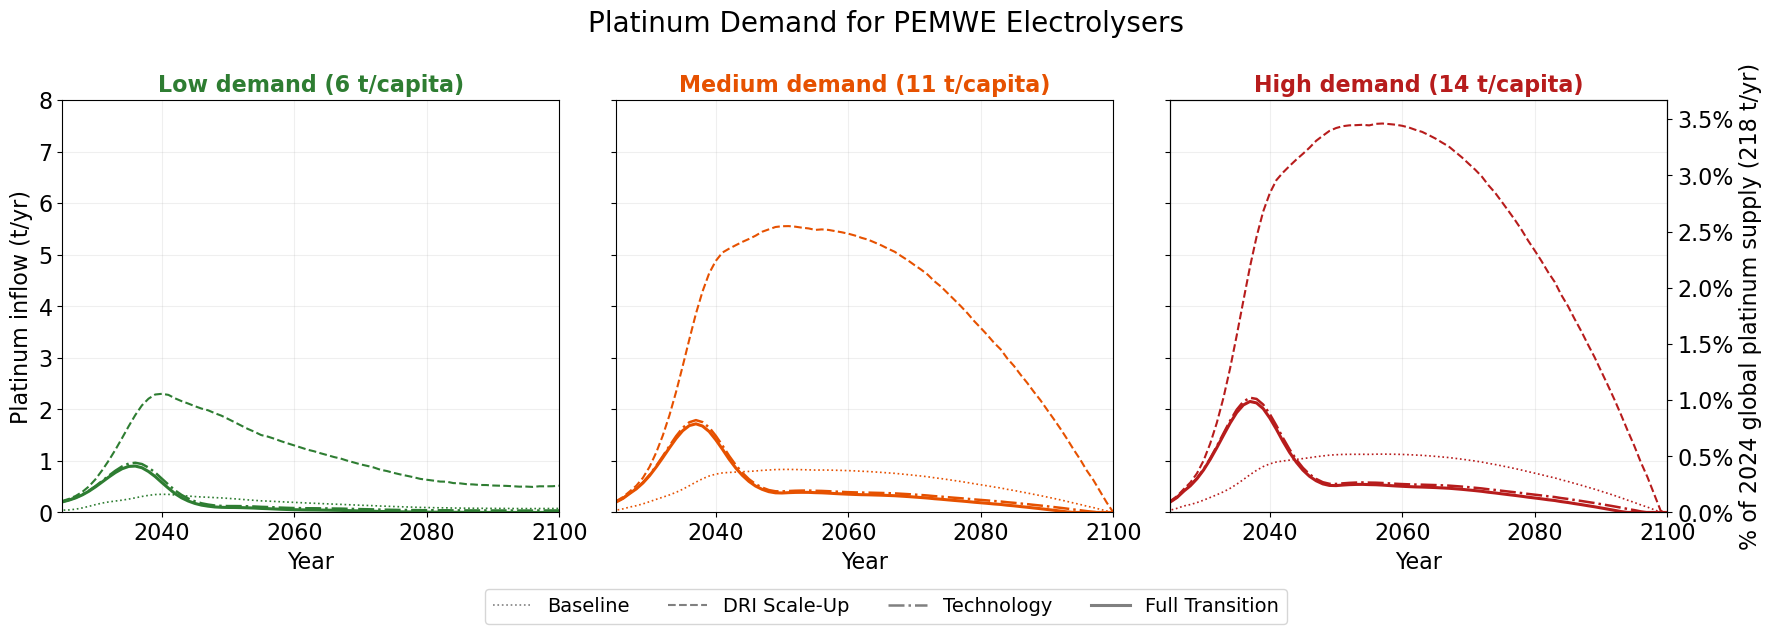

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)
fig.suptitle('Platinum Demand for PEMWE Electrolysers')

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        pt   = scenarios[name]['materials']['platinum_inflow'] * 1000
        ax.plot(scenarios[name]['years'], pt,
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    ax.set_title(demand_labels[demand], fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2025, 2100)
    ax.set_ylim(0, 8)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Platinum inflow (t/yr)')

ax2 = axes[2].twinx()
ax2.set_ylim(0, axes[2].get_ylim()[1] / platinum_supply_2024 * 100)
ax2.set_ylabel('% of 2024 global platinum supply (218 t/yr)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

from matplotlib.lines import Line2D
ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
fig.savefig(viz['CRM'] / 'platinum_demand_all_scenarios.png', dpi=300)
plt.show()

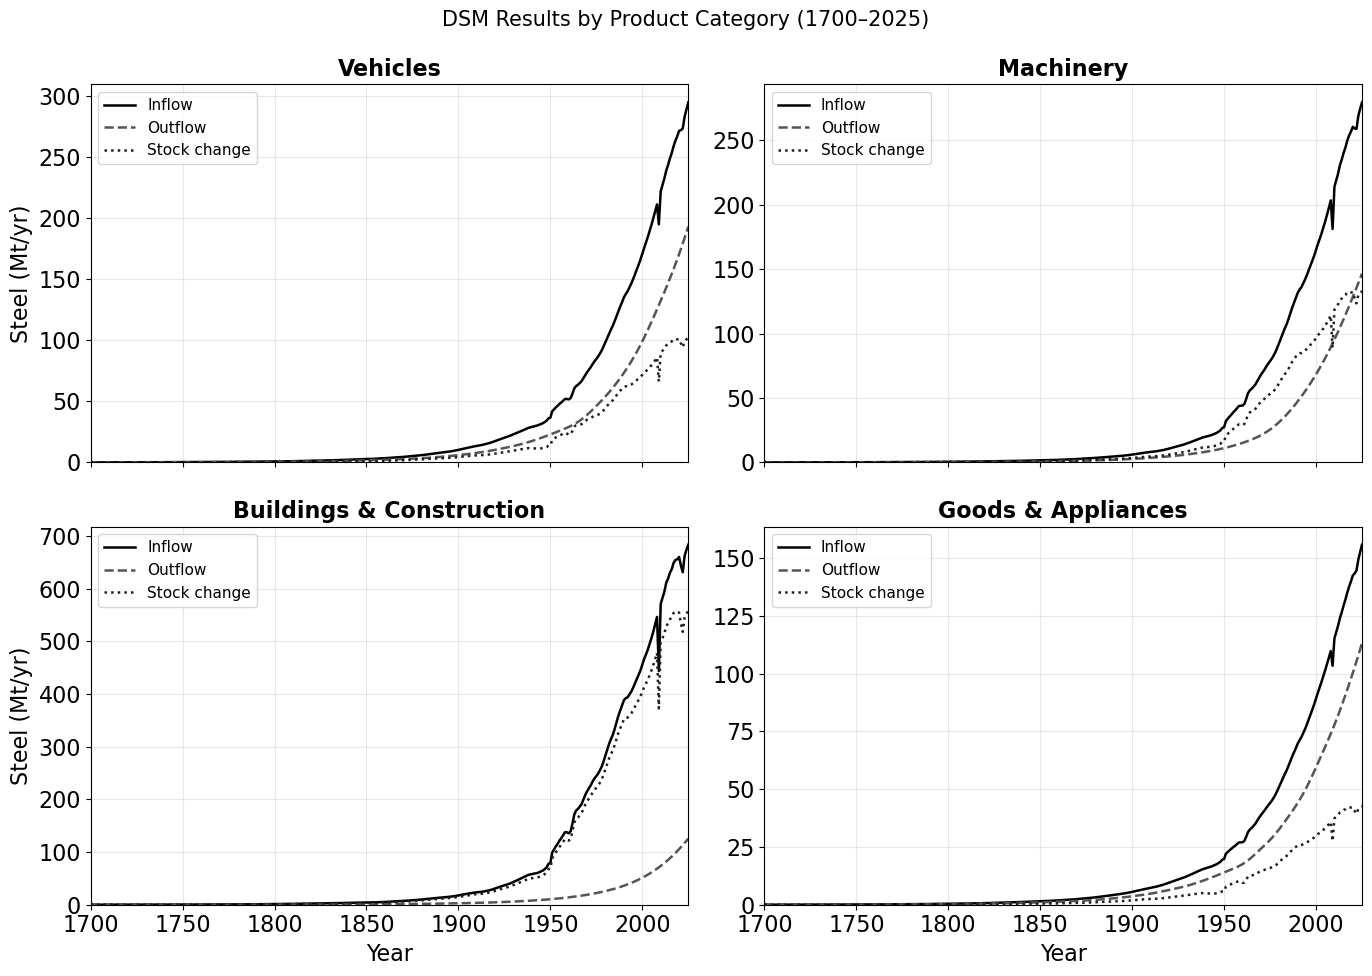

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
fig.suptitle('DSM Results by Product Category (1700–2025)', fontsize=15)

results = scenarios['M-Baseline']['results']
mask = (results['Year'] >= 1700) & (results['Year'] <= 2025)
r = results[mask]

cats = {
    'Vehicles':   ('inflow_vehicles',   'outflow_vehicles',   'stock_change_vehicles'),
    'Machinery':  ('inflow_machinery',  'outflow_machinery',  'stock_change_machinery'),
    'Buildings & Construction': ('inflow_bc', 'outflow_bc', 'stock_change_bc'),
    'Goods & Appliances': ('inflow_appliances', 'outflow_appliances', 'stock_change_appliances'),
}

for ax, (title, (inf_col, out_col, sc_col)) in zip(axes.flat, cats.items()):
    ax.plot(r['Year'], r[inf_col] / 1e6, color='black',   linewidth=1.8, label='Inflow')
    ax.plot(r['Year'], r[out_col] / 1e6, color='#555555', linewidth=1.8, linestyle='--', label='Outflow')
    ax.plot(r['Year'], r[sc_col]  / 1e6, color="#231e1e", linewidth=1.8, linestyle=':', label='Stock change')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(1700, 2025)
    ax.set_ylim(0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)

for ax in axes[1]:
    ax.set_xlabel('Year')
for ax in axes[:, 0]:
    ax.set_ylabel('Steel (Mt/yr)')

plt.tight_layout()
fig.savefig(viz['steel'] / 'dsm_historic_validation.png', dpi=300)
plt.show()